## About Matrix Multiplications

### 1. Introduction

Matrix Multiplication (MatMul)

X @ W = Y

[M x K] @ [K x N] = [M, N]

Block matmul

### Basic dtypes

| Format | Bits | Exponent | Mantissa | Range | Precision |
|--------|------|----------|----------|-------|-----------|
| **FP32** | 32 | 8 | 23 | ~10³⁸ | ~7 decimal digits |
| **FP16** | 16 | 5 | 10 | ~10⁴ | ~3 decimal digits |
| **BF16** | 16 | 8 | 7 | ~10³⁸ | ~2 decimal digits |

FP32

FP16, gradient scaling

BF16

torch.set_matmul_precision

TensorFloat

### Advanced

INT8, group scaling

FLOAT8, e5m2, e4m3, e3m4

MXFP4, NVFP4

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
import triton

DEVICE = triton.runtime.driver.active.get_active_torch_device()

In [2]:
@torch.no_grad()
def deepseek_dist(x, y):
    x, y = x.double(), y.double()
    denom = (x * x + y * y).sum()
    sim = 2 * (x * y).sum() / denom
    return (1 - sim).item()

In [3]:
def prepare_args_fp32_fp32(M, N, K):
    X = torch.randn(M, K, dtype=torch.float32).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.float32).to(DEVICE) / K ** 0.5
    return X, W


def prepare_args_fp16_fp16(M, N, K):
    X = torch.randn(M, K, dtype=torch.float16).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.float16).to(DEVICE) / K ** 0.5
    return X, W


def prepare_args_fp16_fp32(M, N, K):
    X = torch.randn(M, K, dtype=torch.float16).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.float32).to(DEVICE) / K ** 0.5
    return X, W


def prepare_args_bf16_bf16(M, N, K):
    X = torch.randn(M, K, dtype=torch.bfloat16).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.bfloat16).to(DEVICE) / K ** 0.5
    return X, W

In [4]:
from matmul_int8_int8 import matmul_int8_int8
from matmul_fp8_fp8 import matmul_fp8_fp8, alloc_and_quant, scaled_matmul_fp8_fp8



def prepare_args_int8_int8(M, N, K):
    X = torch.randint(-128, 128, (M, K), dtype=torch.int8).to(DEVICE)
    W = torch.randint(-128, 128, (K, N), dtype=torch.int8).to(DEVICE)
    return X, W


def prepare_args_fp8_fp8(M, N, K):
    X = torch.randn(M, K, dtype=torch.bfloat16).to(torch.float8_e4m3fn).to(DEVICE)
    W = (torch.randn(K, N, dtype=torch.bfloat16)  / K ** 0.5).to(torch.float8_e4m3fn).to(DEVICE)
    return X, W

In [5]:
def matmul_autocast_fp8(a, b, transpose_right=False):
    a_fp8, a_scales = alloc_and_quant(a)
    b_fp8, b_scales = alloc_and_quant(b)
    if transpose_right:
        return scaled_matmul_fp8_fp8(a_fp8, b_fp8.T, a_scales, b_scales.T.contiguous())
    return scaled_matmul_fp8_fp8(a_fp8, b_fp8, a_scales, b_scales)


In [6]:
a = torch.randn(1024, 1024, dtype=torch.float32).to(DEVICE)
b = torch.randn(1024, 1024, dtype=torch.float32).to(DEVICE)

a = torch.sign(a) * a ** 2
b = torch.sign(b) * b ** 2

c1 = matmul_autocast_fp8(a, b)
c2 = a @ b

# deepseek_dist(c1, c2)
print(deepseek_dist(c1, c2))

raise

0.000699245285840866


RuntimeError: No active exception to reraise

In [ ]:
@torch.no_grad()
def benchmark_matmul(M, N, K, prepare_args_fn, matmul_fn, quantiles=[0.5, 0.1, 0.9]):
    args = prepare_args_fn(M, N, K)
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: matmul_fn(*args), quantiles=quantiles)
    perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


matmul-performance:
         K        M        N  fp32@fp32_autocast_fp16 (TFLOPS)  fp32@fp32_autocast_fp8 (TFLOPS)  fp8@fp8 (TFLOPS)
0   4096.0   4096.0   4096.0                         71.965406                       110.467261        171.226795
1   8192.0   8192.0   8192.0                         81.752842                       130.329238        163.062996
2  16384.0  16384.0  16384.0                         88.473029                       149.496763        168.678141


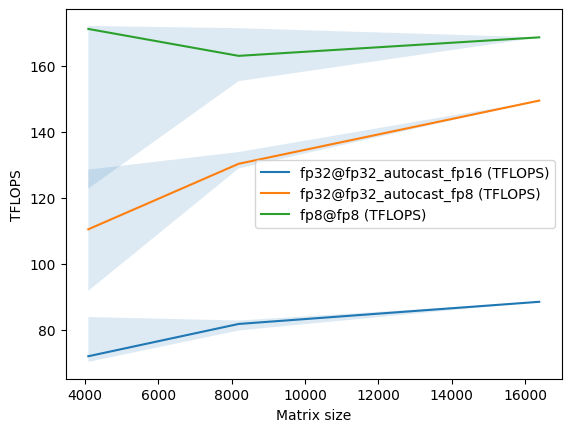

In [ ]:
test_shapes = [
    # [1024, 1024, 1024],
    [4096, 4096, 4096],
    [8192, 8192, 8192],
    [16384, 16384, 16384],
    # [2**14, 2**14, 2**14]
    ]

experiments = [
            # "fp32@fp32",
            # "fp16@fp32",
            # "fp16@fp16",
            # "bf16@bf16",
            # "fp32@fp32_set_float32_matmul_precision",
            "fp32@fp32_autocast_fp16",
            # "fp32@fp32_autocast_bf16",
            "fp32@fp32_autocast_fp8",
            "fp8@fp8",
            # "int8@int8",
            ]

configs = []
configs.append(
    triton.testing.Benchmark(
        x_names=["K", "M", "N"],
        x_vals=[shape for shape in test_shapes],
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        line_vals=experiments,
        line_names=experiments,
        ylabel="TFLOPS",  # Label name for the y-axis
        xlabel="Matrix size",
        plot_name="matmul-performance",  # Name for the plot, used also as a file name for saving the plot.
        args={},
    ))

@triton.testing.perf_report(configs)
def benchmark(M, K, N, provider):

    if provider == "fp32@fp32":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp32_fp32,
            matmul_fn=torch.matmul
        )
    if provider == "fp16@fp16":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp16_fp16,
            matmul_fn=torch.matmul
        )
    # if provider == "fp16@fp32":
    #     perf = benchmark_matmul(
    #         M=M, N=N, K=K,
    #         prepare_args_fn=prepare_args_fp16_fp32,
    #         matmul_fn=torch.matmul
    #     )
    if provider == "bf16@bf16":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_bf16_bf16,
            matmul_fn=torch.matmul
        )
    if provider == "fp32@fp32_set_float32_matmul_precision":
        torch.set_float32_matmul_precision("high")
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp32_fp32,
            matmul_fn=torch.matmul
        )
        torch.set_float32_matmul_precision("highest")
    if provider == "fp32@fp32_autocast_fp16":
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            perf = benchmark_matmul(
                M=M, N=N, K=K,
                prepare_args_fn=prepare_args_fp32_fp32,
                matmul_fn=torch.matmul
            )
    if provider == "fp32@fp32_autocast_bf16":
        with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
            perf = benchmark_matmul(
                M=M, N=N, K=K,
                prepare_args_fn=prepare_args_fp32_fp32,
                matmul_fn=torch.matmul
            )
    if provider == "fp32@fp32_autocast_fp8":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp32_fp32,
            matmul_fn=matmul_autocast_fp8
        )
    if provider == "int8@int8":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_int8_int8,
            matmul_fn=matmul_int8_int8
        )
    if provider == "fp8@fp8":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp8_fp8,
            matmul_fn=matmul_fp8_fp8
        )
    return perf

bench_data = benchmark.run(show_plots=False, print_data=True, return_df=True)[0]

In [ ]:
from matmul_fp8_fp8 import kernel_scaled_matmul_fp8_fp8, kernel_matmul_fp8_fp8

print(kernel_matmul_fp8_fp8.best_config)
print(kernel_scaled_matmul_fp8_fp8.best_config)

GROUP_SIZE_M: 8, BLOCK_SIZE_M: 128, BLOCK_SIZE_N: 128, BLOCK_SIZE_K: 64, num_warps: 4, num_ctas: 1, num_stages: 4, maxnreg: None
GROUP_SIZE_M: 8, BLOCK_SIZE_M: 128, BLOCK_SIZE_N: 128, BLOCK_SIZE_K: 128, num_warps: 8, num_ctas: 1, num_stages: 4, maxnreg: None
